## Robot programming workshop 01 

<div class="alert alert-block alert-info">For this workshop you will be connecting Python to the CoppeliaSim environment and using the line tracker scene to do some initial testing of the API and of the robot within the scene.  Make sure you have save sim.py, simConst.py and remoteApi.dll files to a directory and also downloaded the 01_line_tracker_scene.ttt to the same location</div>

<font color="red"><b>Task 1:</b></font> Change directory - to the working directory where you have saved <b>sim.py, simConst.py</b> and <b>remoteApi.dll</b>  

In [1]:
import sys, os
desiredPath = "C:\\Users\\2326310\\OneDrive - University of Wolverhampton\\Desktop\\ROBOTICS - 2326310\\ROBOTICS" # set this path to your working folder
os.chdir(desiredPath)
print("Current working directory: {}".format(os.getcwd()))   # snity check

Current working directory: C:\Users\2326310\OneDrive - University of Wolverhampton\Desktop\ROBOTICS - 2326310\ROBOTICS


<font color="red"><b>Task 2:</b></font> Load the Python library 

In [2]:
try:
    import sim
except:
    print ('--------------------------------------------------------------')
    print ('"sim.py" could not be imported. This means very probably that')
    print ('either "sim.py" or the remoteApi library could not be found.')
    print ('Make sure both are in the same folder as this file,')
    print ('or appropriately adjust the file "sim.py"')
    print ('--------------------------------------------------------------')
    print ('')

import time

If the above prints the error message check your your path from cell 1 and check that you placed the files sim.py, simConst.py and remoteApi.dll in that directory.<br><br><font color="red"><b>Task 3:</b></font>Test the connection port for this the CoppeliaSim application must be running

In [3]:
print ('Program started')
sim.simxFinish(-1) # just in case, close all opened connections

clientID=sim.simxStart('127.0.0.1',19997,True,True,5000,5) # Connect to CoppeliaSim

if clientID != -1:
    print ('Connected to remote API server')    
else:
    print('Connection failed!!')
    sys.exit('Could not connect')

Program started
Connected to remote API server


If the above fails to run check port number<br><br><font color="red"><b>Task 4:</b></font>Now we are going to load a scene and interrogate it.  In CoppeliaSim select "File"-> "Open scene" and then browse to the folder that contains the O1_line_tracker_scene.ttt open the file and you should see the following:   

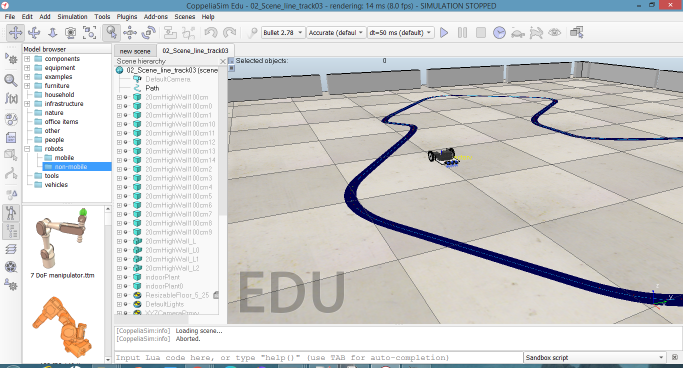

Now run the code in the cell below

In [4]:
print ('Program started')
sim.simxFinish(-1) # just in case, close all opened connections

clientID=sim.simxStart('127.0.0.1',19997,True,True,5000,5) # Connect to CoppeliaSim

if clientID != -1:
    print ('Connected to remote API server')    

    # Now try to retrieve data in a blocking fashion (i.e. a service call):
    res,objs=sim.simxGetObjects(clientID,sim.sim_handle_all,sim.simx_opmode_blocking)
    if res==sim.simx_return_ok:
        print ('Number of objects in the scene: ',len(objs))
    else:
        print ('Remote API function call returned with error code: ',res)

    time.sleep(2)
else:
    print('Connection failed!!')
    sys.exit('Could not connect')

Program started
Connected to remote API server
Number of objects in the scene:  79


If the program above worked it should have seen some 79 objects in the scene<br><br><font color="red"><b>Task 5:</b></font> In the next we are going to connect Python to some of the components belonging to the robot. Below is an image of the CoppeliaSim toobar. To the right hand side, <i>(between default and the clock),</i> are 3 buttons to <font color="green"><b>run</b></font>, <font color="orange"><b>pause</b></font> and <font color="red"><b>stop/reset</b></font> the simulator. 

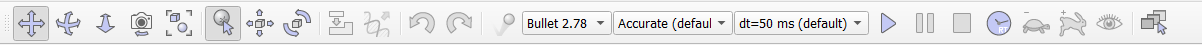

Run the simulator, text will appear in the main viewer but the robot should not move. Now run the cell below: 

In [5]:
print ('Program started')
sim.simxFinish(-1) # just in case, close all opened connections

clientID=sim.simxStart('127.0.0.1',19997,True,True,5000,5) # Connect to CoppeliaSim

if clientID != -1:
    print ('Connected to remote API server')    
else:
    print('Connection failed!!')
    sys.exit('Could not connect')

errCode = [0] * 7
    
## attach actuators    
errCode[0], leftMotor = sim.simxGetObjectHandle(clientID, "DynamicLeftJoint", sim.simx_opmode_oneshot_wait )
errCode[1], rightMotor = sim.simxGetObjectHandle(clientID, "DynamicRightJoint", sim.simx_opmode_oneshot_wait )

## attach sensors 
errCode[2], leftSensor = sim.simxGetObjectHandle(clientID, "LeftSensor", sim.simx_opmode_oneshot_wait )
errCode[3], midSensor = sim.simxGetObjectHandle(clientID, "MiddleSensor", sim.simx_opmode_oneshot_wait )
errCode[4], RightSensor = sim.simxGetObjectHandle(clientID, "RightSensor", sim.simx_opmode_oneshot_wait )

## stop the motors
errCode[5] = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.0, sim.simx_opmode_streaming )    
errCode[6] = sim.simxSetJointTargetVelocity(clientID, rightMotor, 0.0, sim.simx_opmode_streaming )    
time.sleep(2)

sim.simxFinish(-1) # just in case, close all opened connections
print("Number of errors {}".format(errCode))
print("...done")

Program started
Connected to remote API server
Number of errors [0, 0, 0, 0, 0, 1, 1]
...done


Some of the error values are likely to be 0 other might return a 1. Is there an error? Consult the Remote API functions (python) document and check the return values for the <b>simxGetObjectHandle</b> and <b>simxSetJointTargetVelocity</b> methods. Has there been an error?<br><br><font color="red"><b>Task 6:</b></font>Now we are going run the robot and have it turn an arc.  Stop the simulation and restart it, press the run button again, then run the cell below:

In [6]:
print ('Program started')
sim.simxFinish(-1) # just in case, close all opened connections

clientID=sim.simxStart('127.0.0.1',19997,True,True,5000,5) # Connect to CoppeliaSim

if clientID != -1:
    print ('Connected to remote API server')    
else:
    print('Connection failed!!')
    sys.exit('Could not connect')

## attach actuators    
errCode, leftMotor = sim.simxGetObjectHandle(clientID, "DynamicLeftJoint", sim.simx_opmode_oneshot_wait )
errCode, rightMotor = sim.simxGetObjectHandle(clientID, "DynamicRightJoint", sim.simx_opmode_oneshot_wait )

## attach sensors 
errCode, leftSensor = sim.simxGetObjectHandle(clientID, "LeftSensor", sim.simx_opmode_oneshot_wait )
errCode, midSensor = sim.simxGetObjectHandle(clientID, "MiddleSensor", sim.simx_opmode_oneshot_wait )
errCode, RightSensor = sim.simxGetObjectHandle(clientID, "RightSensor", sim.simx_opmode_oneshot_wait )

startTime=time.time()
## move in a circle
errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.6, sim.simx_opmode_streaming )    
errCode = sim.simxSetJointTargetVelocity(clientID, rightMotor, -0.6, sim.simx_opmode_streaming )    
time.sleep(6)
# stop the motors
errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.0, sim.simx_opmode_streaming )    
errCode = sim.simxSetJointTargetVelocity(clientID, rightMotor, 0.0, sim.simx_opmode_streaming )    
time.sleep(0.5)    # give the commands a chance to work  
sim.simxFinish(-1) # just in case, close all opened connections
print("...done")

Program started
Connected to remote API server
...done


The robot should have turned a half circle.  If not you will need to revisit the previous cell and review wat you may have missed.  How would you modify the code above to have the robot turn a full circle?  Reset the simulation and have a go.<br><br><font color="red"><b>Task 7:</b></font> Now we are goinig to slowly turn the robot and drive it over the line.

In [7]:
print ('Program started')
sim.simxFinish(-1) # just in case, close all opened connections

clientID=sim.simxStart('127.0.0.1',19997,True,True,5000,5) # Connect to CoppeliaSim

if clientID != -1:
    print ('Connected to remote API server')    
else:
    print('Connection failed!!')
    sys.exit('Could not connect')

## attach actuators    
errCode, leftMotor = sim.simxGetObjectHandle(clientID, "DynamicLeftJoint", sim.simx_opmode_oneshot_wait )
errCode, rightMotor = sim.simxGetObjectHandle(clientID, "DynamicRightJoint", sim.simx_opmode_oneshot_wait )

## attach sensors 
errCode, leftSensor = sim.simxGetObjectHandle(clientID, "LeftSensor", sim.simx_opmode_oneshot_wait )
errCode, midSensor = sim.simxGetObjectHandle(clientID, "MiddleSensor", sim.simx_opmode_oneshot_wait )
errCode, RightSensor = sim.simxGetObjectHandle(clientID, "RightSensor", sim.simx_opmode_oneshot_wait )

## move in a circle
errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.6, sim.simx_opmode_streaming )    
time.sleep(5)

startTime=time.time()
## forward
errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.6, sim.simx_opmode_streaming )    
errCode = sim.simxSetJointTargetVelocity(clientID, rightMotor, 0.6, sim.simx_opmode_streaming )    
while time.time()-startTime < 15:
    ## sense something here?
    time.sleep(0.005)
errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.0, sim.simx_opmode_streaming )    
errCode = sim.simxSetJointTargetVelocity(clientID, rightMotor, 0.0, sim.simx_opmode_streaming )
time.sleep(1)
sim.simxFinish(-1) # just in case, close all opened connections
print("...done")

Program started
Connected to remote API server
...done


If the was too slow you can try adjusting the parameters to the <b>simxSetJointTargetVelocity</b> method and the sleep period to see what you can achive.<br><br><font color="red"><b>Task 8:</b></font> For this task we are goinig to turn the robot and drive it over the line again but this time reading the output from the three photosensors at the front and returning the results to Python. Reset and run the simulation again and run the cell below.

In [8]:
print ('Program started')
sim.simxFinish(-1) # just in case, close all opened connections

clientID=sim.simxStart('127.0.0.1',19997,True,True,5000,5) # Connect to CoppeliaSim

if clientID != -1:
    print ('Connected to remote API server')
else:
    print('Connection failed!!')
    sys.exit('Could not connect')

## attach actuators
errCode, leftMotor = sim.simxGetObjectHandle(clientID, "DynamicLeftJoint", sim.simx_opmode_oneshot_wait )
errCode, rightMotor = sim.simxGetObjectHandle(clientID, "DynamicRightJoint", sim.simx_opmode_oneshot_wait )

## attach sensors
errCode, leftSensor = sim.simxGetObjectHandle(clientID, "LeftSensor", sim.simx_opmode_oneshot_wait )
errCode, midSensor = sim.simxGetObjectHandle(clientID, "MiddleSensor", sim.simx_opmode_oneshot_wait )
errCode, rightSensor = sim.simxGetObjectHandle(clientID, "RightSensor", sim.simx_opmode_oneshot_wait )

## move in a circle
errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.6, sim.simx_opmode_streaming )
time.sleep(5)

sensorReading= [None, None, None]
startTime=time.time()
## forward
errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.6, sim.simx_opmode_streaming )
errCode = sim.simxSetJointTargetVelocity(clientID, rightMotor, 0.6, sim.simx_opmode_streaming )
while time.time()-startTime < 16:
    ## Read the sensors:
    _, sensorReading[0], _ = sim.simxReadVisionSensor(clientID,leftSensor,sim.simx_opmode_oneshot_wait) # Try to retrieve the streamed data
    _, sensorReading[1], _ = sim.simxReadVisionSensor(clientID,midSensor,sim.simx_opmode_oneshot_wait) # Try to retrieve the streamed data
    _, sensorReading[2], _ = sim.simxReadVisionSensor(clientID,rightSensor,sim.simx_opmode_oneshot_wait) # Try to retrieve the streamed data
    print(sensorReading)
    time.sleep(0.5) # 005)

errCode = sim.simxSetJointTargetVelocity(clientID, leftMotor, 0.0, sim.simx_opmode_streaming )
errCode = sim.simxSetJointTargetVelocity(clientID, rightMotor, 0.0, sim.simx_opmode_streaming )
time.sleep(1)
sim.simxFinish(-1) # just in case, close all opened connections
print("...done")

Program started
Connected to remote API server


KeyboardInterrupt: 

What value does the robot return when it is over the light coloured floor and what value does it return when the line is seen?

<div class="alert alert-block alert-danger">That is the end for this workbook. When you shutdown CoppeliaSim it will offer you the opportunity to save changes, select <b>No</b>. And remember to save your workbook before you shutdown. Next week: we will add some logical structure and OO design to our robot code. </div>